In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tensorflow.python.keras.models import load_model
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

I0000 00:00:1778243550.321812 2007613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778243550.846146 2007613 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778243553.073588 2007613 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 60000, Test samples: 10000


In [4]:
class ContrastiveAutoencoder(nn.Module):
    def __init__(self, emb_dim=2):
        super(ContrastiveAutoencoder, self).__init__()
        self.emb_dim = emb_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(1, 1, kernel_size=5),
            nn.Tanh()
        )

    def forward(self, x):
        embedding = self.encoder(x)
        reconstruction = self.decoder(embedding)
        return reconstruction, embedding

    def get_embedding(self, x):
        return self.encoder(x)

In [5]:
def contrastive_loss(emb1, emb2, label, margin=1.0):
    distance = F.pairwise_distance(emb1, emb2)
    loss = (1 - label) * torch.pow(distance, 2) + \
           label * torch.pow(torch.clamp(margin - distance, min=0.0), 2)
    return loss.mean()

def reconstruction_loss(recon, original):
    """MSE loss для реконструкции"""
    return F.mse_loss(recon, original)

In [6]:
def create_pairs(images, labels):
    """
    Создает пары изображений для contrastive learning
    Возвращает: (img1, img2, target) где target=0 если одинаковые, 1 если разные
    """
    batch_size = images.size(0)
    pairs_img1 = []
    pairs_img2 = []
    pairs_target = []

    for i in range(batch_size):
        if torch.rand(1) > 0.5:
            same_class_idx = (labels == labels[i]).nonzero(as_tuple=True)[0]
            if len(same_class_idx) > 1:
                j = same_class_idx[torch.randint(0, len(same_class_idx), (1,))].item()
                if j != i:
                    pairs_img1.append(images[i])
                    pairs_img2.append(images[j])
                    pairs_target.append(0)
        else:
            diff_class_idx = (labels != labels[i]).nonzero(as_tuple=True)[0]
            if len(diff_class_idx) > 0:
                j = diff_class_idx[torch.randint(0, len(diff_class_idx), (1,))].item()
                pairs_img1.append(images[i])
                pairs_img2.append(images[j])
                pairs_target.append(1)

    if len(pairs_img1) == 0:
        return None, None, None

    return torch.stack(pairs_img1), torch.stack(pairs_img2), torch.tensor(pairs_target, device=device)

In [8]:
from tqdm import tqdm

def train(model, train_loader, epochs=20, lambda_contrast=0.5):
    """
    lambda_contrast: вес contrastive loss (0 - только реконструкция, 1 - только contrastive)
    """
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_recon_loss = 0
        total_contrast_loss = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=True)

        for batch_idx, (images, labels) in enumerate(progress_bar):
            images = images.to(device)
            labels = labels.to(device)

            img1, img2, targets = create_pairs(images, labels)

            optimizer.zero_grad()

            recon, emb = model(images)
            loss_recon = reconstruction_loss(recon, images)

            loss_contrast = torch.tensor(0.0).to(device)
            if img1 is not None and len(img1) > 0:
                img1 = img1.to(device)
                img2 = img2.to(device)
                emb1 = model.get_embedding(img1)
                emb2 = model.get_embedding(img2)
                loss_contrast = contrastive_loss(emb1, emb2, targets)

            loss = loss_recon + lambda_contrast * loss_contrast

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += loss_recon.item()
            total_contrast_loss += loss_contrast.item() if isinstance(loss_contrast, torch.Tensor) else loss_contrast

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Recon': f'{loss_recon.item():.4f}',
                'Contrast': f'{loss_contrast.item():.4f}' if isinstance(loss_contrast, torch.Tensor) else f'{loss_contrast:.4f}'
            })

        avg_loss = total_loss / len(train_loader)
        avg_recon = total_recon_loss / len(train_loader)
        avg_contrast = total_contrast_loss / len(train_loader)

        tqdm.write(f'Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f} (Recon: {avg_recon:.4f}, Contrast: {avg_contrast:.4f})')

In [9]:
def visualize_reconstruction(model, num_samples=10):
    """Визуализация оригинальных и восстановленных изображений"""
    model.eval()
    model.cpu()

    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    indices = torch.randperm(len(images))[:num_samples]
    sample_images = images[indices]
    sample_labels = labels[indices]

    with torch.no_grad():
        recon, emb = model(sample_images)

    sample_images = (sample_images + 1) / 2
    recon = (recon + 1) / 2

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        axes[0, i].imshow(sample_images[i, 0], cmap='gray')
        axes[0, i].set_title(f'Original: {sample_labels[i]}')
        axes[0, i].axis('off')

        axes[1, i].imshow(recon[i, 0], cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
def visualize_embeddings(model, num_samples=500):
    """Визуализация эмбеддингов в 2D пространстве"""
    model.eval()
    model.cpu()

    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            if len(all_embeddings) * images.size(0) >= num_samples:
                break

            images = images[:num_samples - len(all_embeddings)]
            labels = labels[:num_samples - len(all_embeddings)]

            _, embeddings = model(images)
            all_embeddings.append(embeddings.numpy())
            all_labels.append(labels.numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    if all_embeddings.shape[1] != 2:
        print("Applying t-SNE...")
        tsne = TSNE(n_components=2, random_state=42)
        all_embeddings = tsne.fit_transform(all_embeddings)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(all_embeddings[:, 0], all_embeddings[:, 1],
                         c=all_labels, cmap='tab10', alpha=0.6, s=10)
    plt.colorbar(scatter, label='Digit')
    plt.title('Embedding Space Visualization')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()

    from sklearn.metrics import silhouette_score
    if len(set(all_labels)) > 1:
        score = silhouette_score(all_embeddings, all_labels)
        print(f"Silhouette Score: {score:.3f}")

In [11]:
model = ContrastiveAutoencoder(emb_dim=2)
print("Model created with embedding dimension: 2")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

train(model, train_loader, epochs=20, lambda_contrast=0.3)

Model created with embedding dimension: 2
Total parameters: 1,307,165


Epoch 1/20:  15%|█▌        | 72/469 [00:11<01:04,  6.18it/s, Loss=0.1170, Recon=0.0631, Contrast=0.1797]


KeyboardInterrupt: 

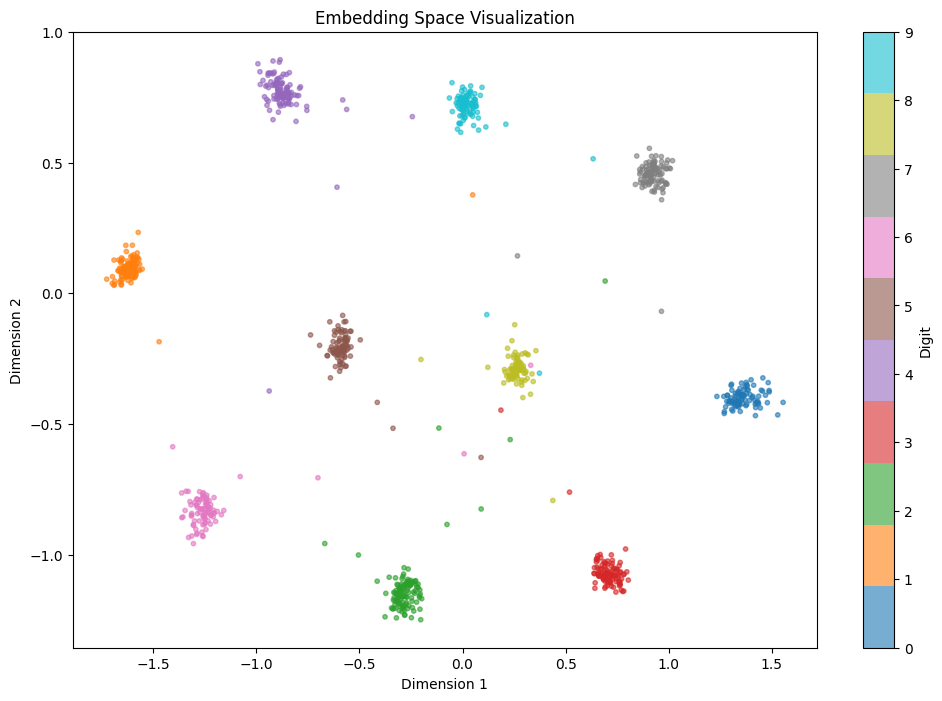

Silhouette Score: 0.872 (higher = better clustering)


In [12]:
# Визуализация пространства эмбеддингов
visualize_embeddings(model, num_samples=1000)

In [ ]:
torch.save(model.state_dict(), 'contrastive_autoencoder_mnist.pth')

In [11]:
def load_model(model, path):
    model.load_state_dict(torch.load(path))
    model.eval()
    print(f"Model loaded from {path}")
    return model

In [12]:
model = load_model(ContrastiveAutoencoder(emb_dim=2), 'contrastive_autoencoder_mnist.pth')

Model loaded from contrastive_autoencoder_mnist.pth


In [13]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for idx in range(len(train_dataset)):
        img_tensor, label = train_dataset[idx]
        img_batch = img_tensor.unsqueeze(0)
        _, embedding = model(img_batch)

        all_embeddings.append(embedding.cpu().numpy())
        all_labels.append(label)

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.array(all_labels)

In [14]:
np.save('all_embeddings.npy', all_embeddings)
np.save('all_labels.npy', all_labels)

In [1]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(all_embeddings[:, 0], all_embeddings[:, 1],
                         c=all_labels, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Digit')
plt.title('Embedding Space Visualization')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

NameError: name 'plt' is not defined

In [17]:
def simple_similarity_search(test_image, model, train_embeddings, train_images, train_labels, k=5):
    """
    Args:
        test_image: тензор [1, 1, 28, 28]
        model: обученная модель
        train_embeddings: numpy array [num_train, emb_dim]
        train_images: numpy array [num_train, 1, 28, 28] или список
        train_labels: numpy array [num_train]
        k: число соседей
    """
    model.eval()
    with torch.no_grad():
        test_emb = model.get_embedding(test_image).cpu().numpy()

    distances = np.linalg.norm(train_embeddings - test_emb, axis=1)
    nearest_idx = np.argsort(distances)[:k]

    fig, axes = plt.subplots(1, k+1, figsize=(3*(k+1), 3))

    test_img = test_image.cpu().squeeze().numpy()
    axes[0].imshow(test_img, cmap='gray')
    axes[0].set_title("Test image", fontsize=10)
    axes[0].axis('off')

    for i, idx in enumerate(nearest_idx):
        img = train_images[idx][0].squeeze()
        axes[i+1].imshow(img, cmap='gray')
        axes[i+1].set_title(f"Label: {train_labels[idx]}\nDist: {distances[idx]:.3f}", fontsize=10)
        print(all_embeddings[idx])
        axes[i+1].axis('off')

    plt.show()
    return nearest_idx

In [18]:
test_image = next(iter(test_loader))[0][0]
print(test_image.shape)

torch.Size([1, 28, 28])


[0.95920825 0.45331815]
[0.9589671  0.45207402]
[0.9597784  0.45209017]
[0.95820236 0.45391527]
[0.9581332  0.45399573]


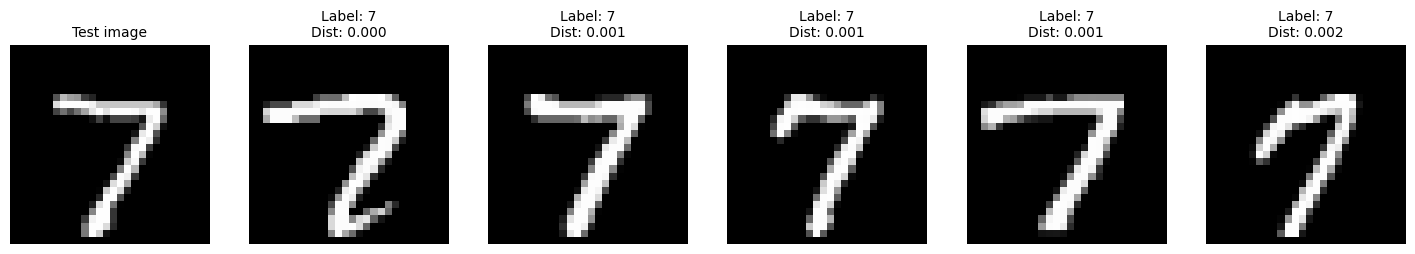

In [19]:
nearest = simple_similarity_search(test_image.unsqueeze(0), model, all_embeddings, train_dataset, all_labels, k=5)

[0.95920825 0.45331815]
[0.9589671  0.45207402]
[0.9597784  0.45209017]
[0.95820236 0.45391527]
[0.9581332  0.45399573]


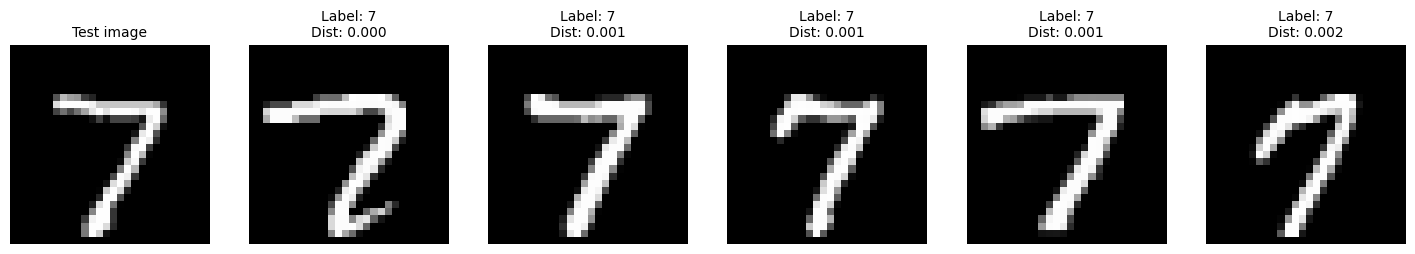

[ 0.27560326 -0.29199955]
[ 0.2763459  -0.29144442]
[ 0.27550358 -0.2930425 ]
[ 0.27718574 -0.29262233]
[ 0.27505124 -0.29113907]


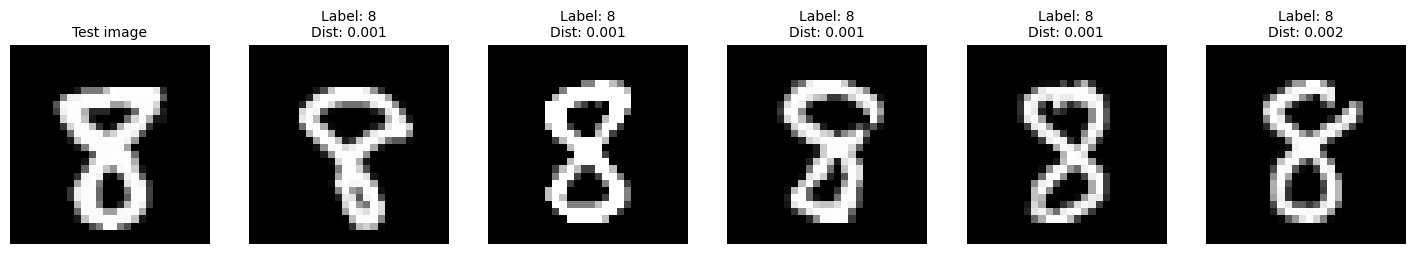

[-0.26519656 -1.1272882 ]
[-0.26465628 -1.1283375 ]
[-0.2652442 -1.1272651]
[-0.2662883 -1.127376 ]
[-0.26319498 -1.1292377 ]


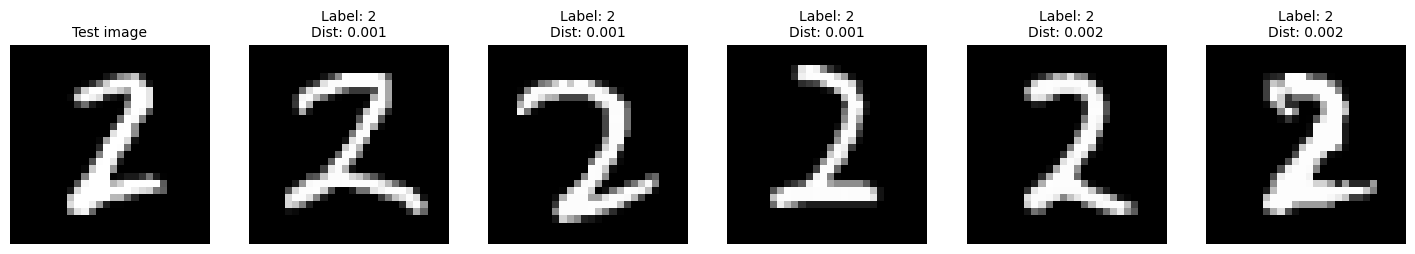

[-1.300432  -0.8719475]
[-1.3014381  -0.87144196]
[-1.3008207 -0.87285  ]
[-1.298306 -0.869154]
[-1.3026757 -0.8729485]


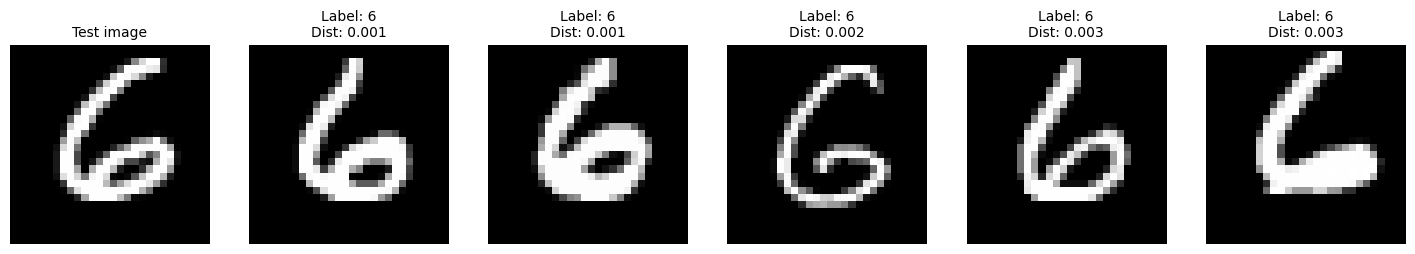

[-0.26272297 -1.1047975 ]
[-0.26133788 -1.1048172 ]
[-0.26100144 -1.1047183 ]
[-0.2602453 -1.1032811]
[-0.25972137 -1.1050472 ]


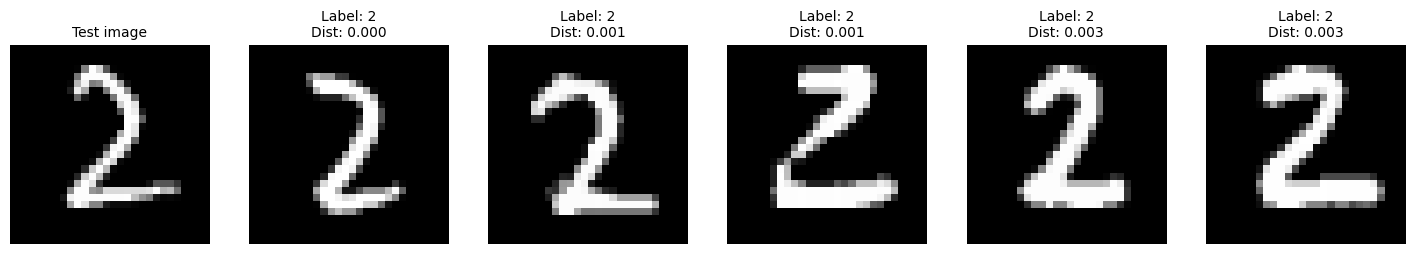

[-1.6485962   0.05327534]
[-1.6508403  0.0550191]
[-1.6501093   0.05545365]
[-1.6483862   0.04993262]
[-1.648734   0.0558634]


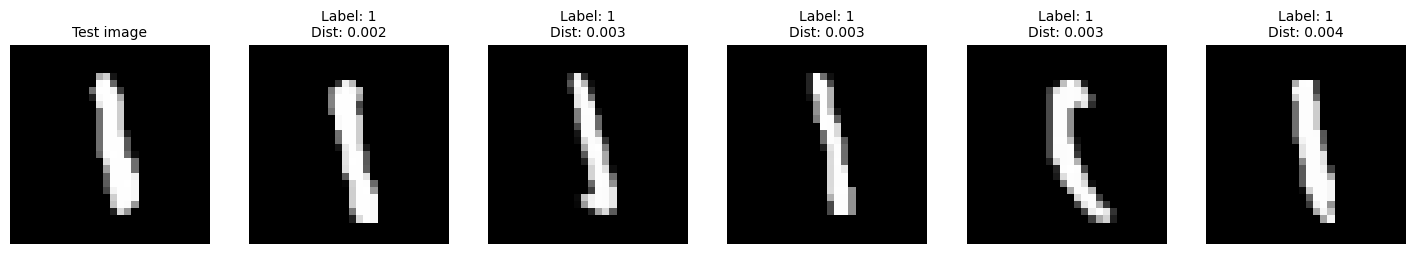

[-1.6326096   0.09352138]
[-1.6312106   0.09381398]
[-1.6338404   0.09329119]
[-1.631541    0.09471234]
[-1.6316046   0.09517633]


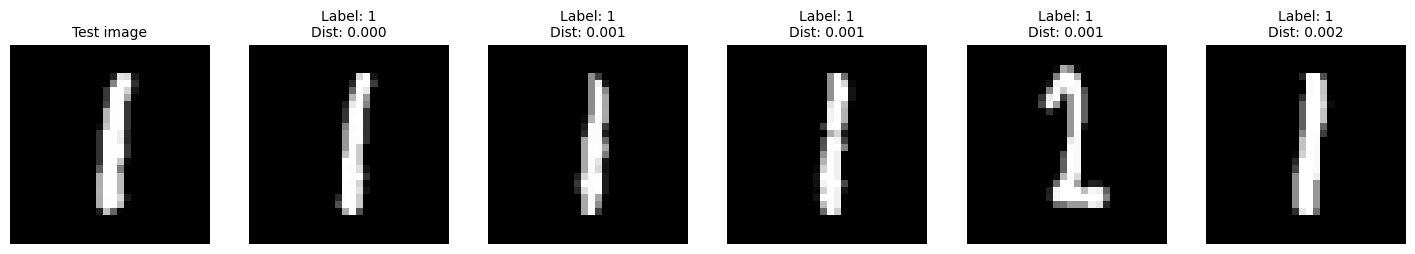

[ 1.4459169  -0.43785837]
[ 1.4463074 -0.4383631]
[ 1.4426254  -0.43937314]
[ 1.4432057  -0.44051674]
[ 1.4425056 -0.4378136]


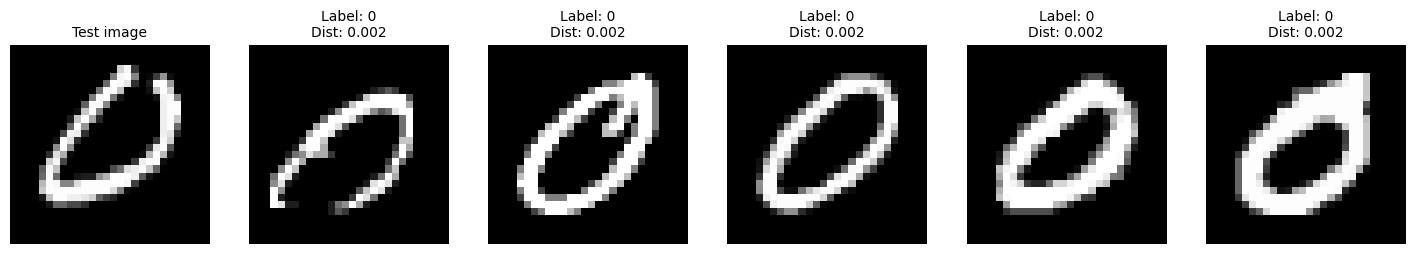

[-0.90920913  0.70949566]
[-0.9133064  0.7087344]
[-0.9078427   0.71064156]
[-0.91476667  0.70983094]
[-0.9155927  0.7118995]


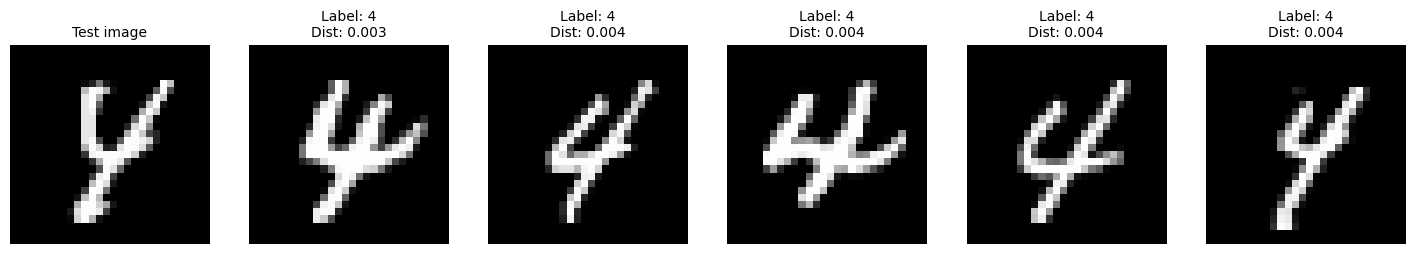

In [27]:
for i, batch in enumerate(test_loader):
    if i == 9:
        break
    test_image = batch[0][0]
    nearest = simple_similarity_search(test_image.unsqueeze(0), model, all_embeddings, train_dataset, all_labels, k=5)

# Мое изображение

In [69]:
from PIL import Image, ImageFilter
import torch
from torchvision import transforms
import torchvision.transforms.functional as F

img_path = "data/my5_2.jpeg"
img = Image.open(img_path).convert("L")  # градации серого
thick = img.filter(ImageFilter.MinFilter(size=25))  # 3, 5, 7 — радиус утолщения
thick.save("digit_thick.jpeg")

In [70]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),                # -> (1, 28, 28), значения [0, 1]
    transforms.Lambda(lambda x: 1.0 - x),
    transforms.Normalize((0.5,), (0.5,))  # как в обучении MNIST, если так было
])

tensor_image = transform(thick)          # shape: (1, 28, 28)
# если нужен batch: tensor = tensor.unsqueeze(0)  # shape: (1, 1, 28, 28)

print(tensor_image.shape)

torch.Size([1, 28, 28])


[-0.7532295  -0.19637915]
[-0.7926885  -0.26904896]
[-0.7574624  -0.25299874]
[-0.7586801  -0.26685402]
[-0.72943115 -0.2068013 ]


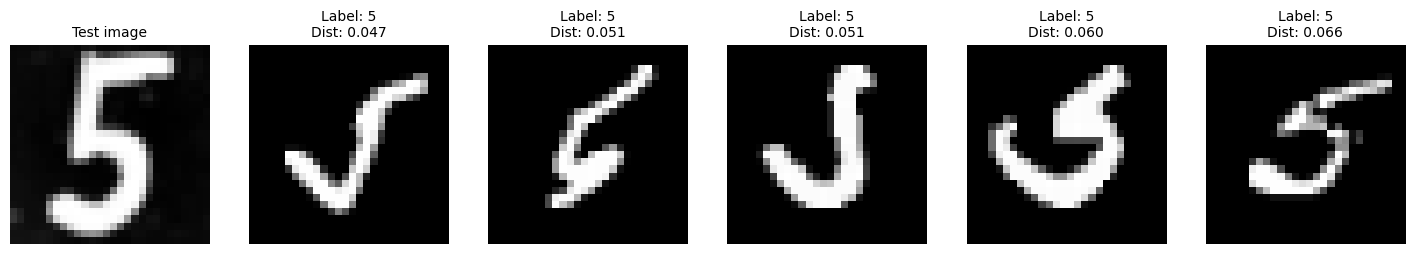

In [71]:
nearest = simple_similarity_search(tensor_image.unsqueeze(0), model, all_embeddings, train_dataset, all_labels, k=5)